# 031 — Evaluation: heteroscedastic (Laplace-beta NLL)

Quantitative comparison of `unet_nll`, `resunet_nll`, `attention_unet_nll` — trained with the unified Laplace-beta NLL loss (`021_training_nll.ipynb`, `fixing.md` #10) — on the held-out test set. `efficientnet_unet_nll`/`efficientnet_unet_nll_ft` — also trained with the unified Laplace-beta NLL loss since `fixing.md` #10's Round 2 collapse — are evaluated separately in `032_evaluation_efficientnet.ipynb` alongside their deterministic EfficientNet siblings. Same block layout as `030_evaluation.ipynb` — see its title cell for the full table of companion notebooks.

Metrics (`mae`/`ssim`/`psnr`) are computed from the `mu` channel only (`scripts.metrics.Mu*Metric`), so they stay directly comparable to `030`'s numbers; `loss` here is the Laplace-beta NLL itself, not `combined_loss`, so it is *not* comparable in scale to `030`'s `loss` column.


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.


In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check.


In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.trainer_nll import load_model_nll

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Build the test dataset

Artwork-and-mockups split, same as the notebook that trained these checkpoints — required so the reported test metrics are on data none of them saw during training or validation.


In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
_, _, test_pairs = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

test_ds = build_dataset(
    test_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)
print(f"Test pairs: {len(test_pairs)} | Test batches: {len(test_ds)}")

Test pairs: 135 | Test batches: 17


2026-08-26 11:40:22.283499: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-26 11:40:22.283518: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-26 11:40:22.283523: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-26 11:40:22.283534: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-26 11:40:22.283541: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Evaluate all three NLL architectures

Checkpoints load from `models/nll/<arch>/best_model.keras` (`021_training_nll.ipynb`), recompiled with `loss_name="laplace_nll"` — the single loss all three now train with, so there is no separate "beta" companion notebook for these architectures anymore (see `fixing.md` #10).


In [4]:
ARCHS = ["unet_nll", "resunet_nll", "attention_unet_nll"]
LOSS_NAME = "laplace_nll"
MODEL_DIR = settings.MODELS_DIR / "nll"
results: dict = {}

for arch in ARCHS:
    try:
        model = load_model_nll(
            arch, model_dir=MODEL_DIR, loss_name=LOSS_NAME, beta=settings.NLL_BETA
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    print(f"Evaluating {arch}...")
    metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
    results[arch] = metrics
    print(f"  {arch}: { {k: f'{v:.4f}' for k, v in metrics.items()} }")


Evaluating unet_nll...


2026-08-26 11:40:23.114285: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  unet_nll: {'loss': '-0.3458', 'mae': '0.1219', 'psnr': '17.6925', 'ssim': '0.4874'}
Evaluating resunet_nll...
  resunet_nll: {'loss': '-0.4044', 'mae': '0.1105', 'psnr': '18.5889', 'ssim': '0.4292'}
Evaluating attention_unet_nll...
  attention_unet_nll: {'loss': '-0.3863', 'mae': '0.1163', 'psnr': '18.0024', 'ssim': '0.4656'}


## 3. Comparison table


In [5]:
if results:
    col_w = 24
    headers = ["architecture"] + list(next(iter(results.values())).keys())
    print("".join(h.ljust(col_w) for h in headers))
    print("-" * (col_w * len(headers)))
    for arch, metrics in results.items():
        row = [arch] + [f"{v:.4f}" for v in metrics.values()]
        print("".join(c.ljust(col_w) for c in row))

architecture            loss                    mae                     psnr                    ssim                    
------------------------------------------------------------------------------------------------------------------------
unet_nll                -0.3458                 0.1219                  17.6925                 0.4874                  
resunet_nll             -0.4044                 0.1105                  18.5889                 0.4292                  
attention_unet_nll      -0.3863                 0.1163                  18.0024                 0.4656                  


## 4. Bar chart comparison


/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4785/3988902048.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4785/3988902048.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4785/3988902048.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_4785/3988902048.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

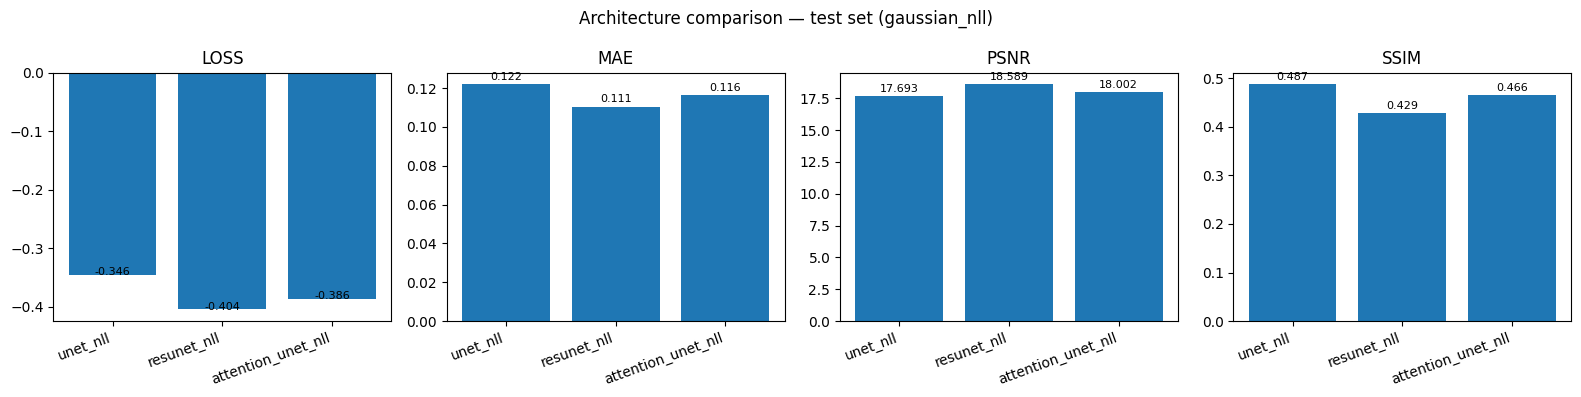

In [6]:
if results:
    metric_keys = list(next(iter(results.values())).keys())
    n = len(metric_keys)
    archs = list(results.keys())
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle("Architecture comparison — test set (gaussian_nll)")
    for ax, key in zip(axes, metric_keys):
        vals = [results[a][key] for a in archs]
        bars = ax.bar(archs, vals)
        ax.set_title(key.upper())
        ax.set_xticklabels(archs, rotation=20, ha="right")
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()